# Deep Kernel Active Learning Results
This notebook generates the validation and optimization plots for the Composites Part A paper.

In [186]:
import torch
import gpytorch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (8, 6)
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(f"Configuration Loaded.")

Configuration Loaded.


## 2. High-Capacity Model Definition
**Crucial:** We redefine the model class here to match the "High-Capacity" architecture (Matern Kernel, ARD, GELU) used in the final training run. This prevents loading errors from the old `model_definitions.py`.

In [187]:
class DeepKernelResidual(torch.nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, mlp_depth: int = 6, 
                 skip_every: int = 2, use_dense: bool = False):
        super().__init__()
        self.skip_every = skip_every
        self.use_dense = use_dense
        
        # Calculate dimensions with growth factor
        dims = [input_dim]
        growth_rate = (latent_dim - input_dim) / max(mlp_depth - 1, 1)
        for i in range(1, mlp_depth):
            next_dim = int(input_dim + i * growth_rate)
            dims.append(max(next_dim, latent_dim // 2))
        dims[-1] = latent_dim
        
        self.activation = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(p=0.1)
        self.layers = torch.nn.ModuleList()
        self.skip_layers = torch.nn.ModuleDict()
        
        for i in range(len(dims) - 1):
            self.layers.append(torch.nn.Linear(dims[i], dims[i+1]))
        
        # Skip connections
        for i in range(0, len(dims) - skip_every, skip_every):
            if dims[i] != dims[i + skip_every]:
                self.skip_layers[f"skip_{i}"] = torch.nn.Linear(dims[i], dims[i + skip_every])
        
        # Init
        for layer in self.layers:
            torch.nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    
    def forward(self, x):
        residual_stack = [x]
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                x = self.dropout(x)
            residual_stack.append(x)
            
            # Apply skip connection
            if i >= self.skip_every - 1 and (i + 1) % self.skip_every == 0:
                skip_from = i - self.skip_every + 1
                skip_tensor = residual_stack[skip_from]
                skip_key = f"skip_{skip_from}"
                
                if skip_key in self.skip_layers:
                    skip_tensor = self.skip_layers[skip_key](skip_tensor)
                elif skip_tensor.shape[-1] != x.shape[-1]:
                    continue # specific dimension mismatch safety

                x = torch.cat([x, skip_tensor], dim=-1) if self.use_dense else x + skip_tensor
        return x

class DeepKernelGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        latent_dim = feature_extractor.layers[-1].out_features
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5)
        )
        self.feature_extractor = feature_extractor

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## 3. Helper Functions

In [188]:
def calculate_elliptical_volume(geometry_np, thickness=2.0):
    a_plies = geometry_np[:, 0:6]
    b_plies = geometry_np[:, 6:12]
    ply_areas = np.pi * a_plies * b_plies
    return np.sum(ply_areas, axis=1) * (thickness)

def plot_results(results_df, train_loss, val_rmse, epochs, category_id):
    """
    Generates and saves publication-ready plots (300 DPI).
    """
    # --- PLOT 1: Training Dynamics (Loss & RMSE) ---
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    
    # Left Axis: Loss
    color1 = 'tab:blue'
    ax1.set_xlabel('Epochs', fontsize=14, fontname='serif')
    ax1.set_ylabel('Negative Log Likelihood (Loss)', color=color1, fontsize=14, fontname='serif')
    line1 = ax1.plot(epochs, train_loss, color=color1, linewidth=2, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right Axis: RMSE
    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Validation RMSE [MPa]', color=color2, fontsize=14, fontname='serif')
    line2 = ax2.plot(epochs, val_rmse, color=color2, linewidth=2, linestyle='--', label='Val RMSE')
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=12)

    # Combined Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=12, frameon=True, framealpha=0.9)
    
    plt.title(f'Training Dynamics: Category {category_id}', fontsize=16, fontname='serif')
    plt.tight_layout()
    
    # SAVE FIGURE 1
    filename_dynamics = f'Publication_Training_Curves_Cat{category_id}.png'
    plt.savefig(filename_dynamics, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename_dynamics}")
    plt.show()

    # --- PLOT 2: Predicted vs True (Validation) ---
    fig2, ax = plt.subplots(figsize=(8, 6))
    
    y_true = results_df['Strength']
    y_pred = results_df['Predicted_Strength']
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Scatter with error coloring
    sc = ax.scatter(y_true, y_pred, c=results_df['Abs_Error'], cmap='coolwarm', 
                    s=100, edgecolors='k', alpha=0.9, zorder=3)
    
    # Error bars
    ax.errorbar(y_true, y_pred, yerr=results_df['Uncertainty_Sigma']*2, 
                fmt='none', ecolor='gray', elinewidth=1, capsize=3, alpha=0.4, zorder=2)
    
    # Ideal line
    min_v = min(y_true.min(), y_pred.min()) - 5
    max_v = max(y_true.max(), y_pred.max()) + 5
    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=2, alpha=0.7, label='Ideal Fit')
    
    # Text Box
    text_str = f'$R^2 = {r2:.2f}$\nRMSE = {rmse:.2f} MPa'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.92, text_str, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props, fontname='serif')
    
    cbar = plt.colorbar(sc)
    cbar.set_label('Absolute Error [MPa]', fontsize=12)
    
    ax.set_xlabel('Experimental Strength [MPa]', fontsize=14, fontname='serif')
    ax.set_ylabel('Predicted Strength [MPa]', fontsize=14, fontname='serif')
    ax.set_title(f'Validation Accuracy: Category {category_id}', fontsize=16, fontname='serif')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # SAVE FIGURE 2
    filename_val = f'Publication_Validation_Scatter_Cat{category_id}.png'
    plt.savefig(filename_val, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename_val}")
    plt.show()

## 4. GPU-Accelerated Training Loop


In [189]:
def run_specific_validation(category_id, target_indices):
    # 1. SETUP DEVICE
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
        torch.cuda.empty_cache()
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not found. Falling back to CPU.")

    print(f"--- Loading Data for Category {category_id} ---")
    file_path = 'Data_v4.xlsx'
    sheet_name = f'Elips{category_id}'
    
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength']).reset_index(drop=True)
        df['Original_ID'] = df.index 
    except Exception as e:
        print(f"Error loading data: {e}")
        return None, None, None, None, None

    # SPLIT DATA
    valid_indices = [idx for idx in target_indices if idx in df.index]
    test_df = df.loc[valid_indices].copy()
    train_df = df.drop(valid_indices).copy()
    
    feature_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
    X_train = train_df[feature_cols].values
    y_train = train_df['Strength'].values
    X_test = test_df[feature_cols].values
    y_test = test_df['Strength'].values

    # Scaling
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    X_train_scaled = (X_train - a_min) / (a_max - a_min)
    X_test_scaled = (X_test - a_min) / (a_max - a_min)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    # GPU Tensors
    train_x = torch.tensor(X_train_scaled, dtype=torch.float64, device=device)
    train_y = torch.tensor(y_train_scaled, dtype=torch.float64, device=device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float64, device=device)

    # INITIALIZE MODEL
    feature_extractor = DeepKernelResidual(
        input_dim=X_train.shape[1], 
        latent_dim=config['MODEL']['LATENT_DIM'], 
        mlp_depth=config['MODEL']['MLP_DEPTH']
    ).double().to(device)
    
    likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to(device)
    model = DeepKernelGP(train_x, train_y, likelihood, feature_extractor).double().to(device)

    # TRAIN
    model.train()
    likelihood.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    num_epochs = config['MODEL']['NUM_EPOCHS']
    loss_hist, rmse_hist, epochs = [], [], []

    print("--- Starting Training on GPU ---")
    for i in range(num_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        if i % 50 == 0:
            loss_hist.append(loss.item())
            epochs.append(i)
            # Fast Validation
            model.eval()
            with torch.no_grad(), gpytorch.settings.fast_pred_var():
                val_pred = likelihood(model(test_x)).mean
                val_phys = scaler_y.inverse_transform(val_pred.cpu().numpy().reshape(-1,1)).flatten()
                rmse_hist.append(np.sqrt(mean_squared_error(y_test, val_phys)))
            model.train()

        if (i+1) % 500 == 0:
            print(f"Epoch {i+1}/{num_epochs} - Loss: {loss.item():.3f} - Val RMSE: {rmse_hist[-1]:.3f}")

    # FINAL EVALUATION
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed = likelihood(model(test_x))
        pred_mean = scaler_y.inverse_transform(observed.mean.cpu().numpy().reshape(-1, 1)).flatten()
        lower, upper = observed.confidence_region()
        lower_phys = scaler_y.inverse_transform(lower.cpu().numpy().reshape(-1, 1)).flatten()
        upper_phys = scaler_y.inverse_transform(upper.cpu().numpy().reshape(-1, 1)).flatten()
        
    results_df = test_df.copy()
    results_df['Predicted_Strength'] = pred_mean
    results_df['Uncertainty_Sigma'] = (upper_phys - lower_phys) / 4.0
    results_df['Abs_Error'] = np.abs(results_df['Strength'] - pred_mean)
    
    geom_np = results_df[feature_cols].values
    results_df['Volume_mm3'] = calculate_elliptical_volume(geom_np, config['OPTIMIZATION']['THICKNESS_CONSTANT'])
    
    plot_results(results_df, loss_hist, rmse_hist, epochs, category_id=category_id)
    
    # RETURN THE TRAINED MODEL OBJECTS
    return results_df, df, model, likelihood, scaler_y

## 5. Execution & Results

✅ GPU Detected: NVIDIA GeForce RTX 3070
--- Loading Data for Category 0 ---
--- Starting Training on GPU ---
Epoch 500/15000 - Loss: 1.343 - Val RMSE: 9.555
Epoch 1000/15000 - Loss: 1.243 - Val RMSE: 9.222
Epoch 1500/15000 - Loss: 1.291 - Val RMSE: 7.505
Epoch 2000/15000 - Loss: 1.251 - Val RMSE: 6.306
Epoch 2500/15000 - Loss: 1.186 - Val RMSE: 6.495
Epoch 3000/15000 - Loss: 1.088 - Val RMSE: 7.683
Epoch 3500/15000 - Loss: 1.188 - Val RMSE: 4.102
Epoch 4000/15000 - Loss: 1.002 - Val RMSE: 8.083
Epoch 4500/15000 - Loss: 1.107 - Val RMSE: 4.623
Epoch 5000/15000 - Loss: 1.101 - Val RMSE: 4.420
Epoch 5500/15000 - Loss: 0.957 - Val RMSE: 6.084
Epoch 6000/15000 - Loss: 0.831 - Val RMSE: 7.335
Epoch 6500/15000 - Loss: 0.790 - Val RMSE: 6.828
Epoch 7000/15000 - Loss: 0.916 - Val RMSE: 5.738
Epoch 7500/15000 - Loss: 0.829 - Val RMSE: 5.027
Epoch 8000/15000 - Loss: 0.921 - Val RMSE: 8.724
Epoch 8500/15000 - Loss: 0.751 - Val RMSE: 5.546
Epoch 9000/15000 - Loss: 0.888 - Val RMSE: 4.800
Epoch 9500

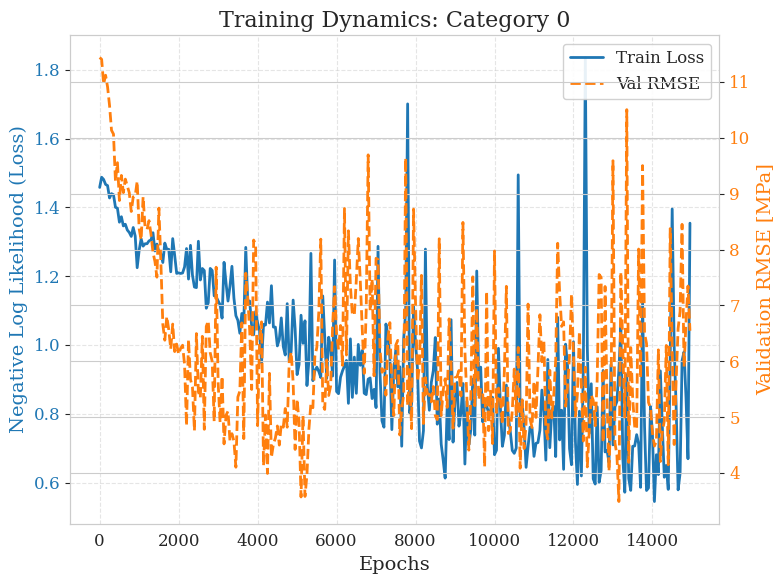

✅ Saved: Publication_Validation_Scatter_Cat0.png


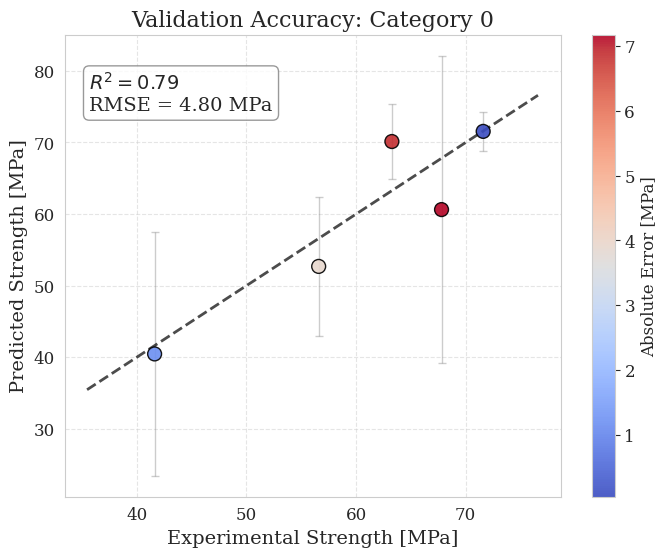


--- Validation Results (Requested Specimens) ---
 Original_ID  Strength  Predicted_Strength  Abs_Error   Volume_mm3
          90     67.80           60.627460   7.172540  9343.096552
           3     41.62           40.458682   1.161318  3666.050131
          28     56.59           52.687281   3.902719  4209.734156
          37     63.27           70.136635   6.866635  8796.459430
          49     71.60           71.552940   0.047060 16461.945505


In [190]:
CATEGORY = 0
# Explicitly requested specimens
SPECIMENS = [90, 3, 28, 37, 49]

# Capture the outputs!
results_df, full_df, model, likelihood, scaler = run_specific_validation(CATEGORY, SPECIMENS)

print("\n--- Validation Results (Requested Specimens) ---")
display_cols = ['Original_ID', 'Strength', 'Predicted_Strength', 'Abs_Error', 'Volume_mm3']
print(results_df[display_cols].to_string(index=False))

## 6. Pareto Context Visualization

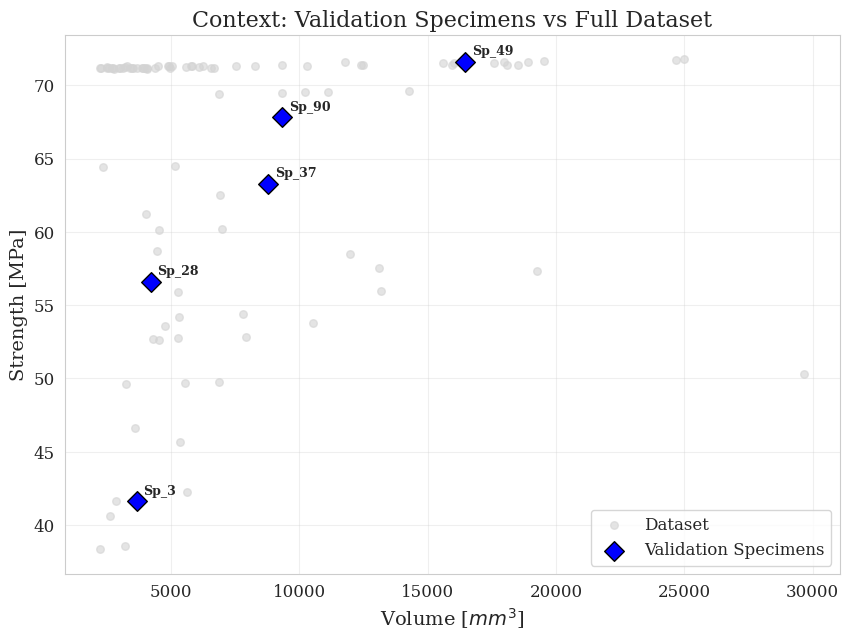

In [193]:
def plot_pareto_context(full_df, validation_df):
    # Calculate Metrics for full dataset
    feature_cols = [c for c in full_df.columns if c.startswith(('a_ply', 'b_ply'))]
    geom_np = full_df[feature_cols].values
    full_df['Volume_mm3'] = calculate_elliptical_volume(geom_np)
    
    plt.figure(figsize=(10, 7))
    
    # Plot all points
    plt.scatter(full_df['Volume_mm3'], full_df['Strength'], 
                c='lightgray', s=30, alpha=0.6, label='Dataset')
    
    # Plot Validation Points
    plt.scatter(validation_df['Volume_mm3'], validation_df['Strength'], 
                c='blue', s=100, marker='D', edgecolors='k', zorder=5, 
                label='Validation Specimens')
    
    # Annotate specific IDs
    for _, row in validation_df.iterrows():
        plt.annotate(f"Sp_{row['Original_ID']}", 
                     (row['Volume_mm3'], row['Strength']),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=9, fontweight='bold')

    plt.xlabel('Volume [$mm^3$]')
    plt.ylabel('Strength [MPa]')
    plt.title(f'Context: Validation Specimens vs Full Dataset')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_pareto_context(full_df, results_df)

## 7. Final Design Recommendation (Pure Exploitation)
Now that the model is trained, we "turn off" exploration. We scan 2 million random designs and select the ones with the best predicted trade-off (Mean Strength vs Volume), ignoring uncertainty.


In [194]:
def get_final_recommendations(category_id, model, likelihood, scaler, n_candidates=2000000):
    print(f"--- Generating Recommendations for Category {category_id} ---")
    
    # 0. Setup Device
    device = next(model.parameters()).device  # Auto-detect device from model
    
    # Get Bounds from Config
    a_min = config['OPTIMIZATION']['A_PLY_MIN']
    a_max = config['OPTIMIZATION']['A_PLY_MAX']
    thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    
    # 1. Generate Random Candidates
    candidates = np.random.randint(a_min, a_max + 1, size=(n_candidates, 12))
    
    # 2. Apply Constraints
    a = candidates[:, 0:6]
    b = candidates[:, 6:12]
    
    mask_aspect = np.all(b <= a, axis=1)
    
    if category_id == 0:
        mask_a = np.all(a[:, :-1] < a[:, 1:], axis=1)
        mask_b = np.all(b[:, :-1] < b[:, 1:], axis=1)
        valid_mask = mask_aspect & mask_a & mask_b
    else:
        mask_support = np.all(a[:, :-1] <= b[:, 1:], axis=1)
        mask_growth = np.all(a[:, :-1] <= a[:, 1:], axis=1)
        valid_mask = mask_aspect & mask_support & mask_growth
        
    valid_candidates = candidates[valid_mask]
    print(f"Valid Candidates found: {len(valid_candidates)} / {n_candidates}")
    
    # 3. Predict (Batched)
    batch_size = 10000
    pred_means = []
    
    # Scale Inputs
    inputs_scaled = (valid_candidates - a_min) / (a_max - a_min)
    inputs_tensor = torch.tensor(inputs_scaled, dtype=torch.float64, device=device) # Match model dtype/device
    
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(inputs_tensor), batch_size):
            batch = inputs_tensor[i:i+batch_size]
            output = likelihood(model(batch))
            pred_means.append(output.mean.cpu().numpy()) # Move to CPU
            
    pred_means = np.concatenate(pred_means)
    
    # Unscale Strength
    pred_strength_phys = scaler.inverse_transform(pred_means.reshape(-1, 1)).flatten()
    
    # 4. Calculate Volume & Score
    vol_phys = calculate_elliptical_volume(valid_candidates, thickness=thickness)
    
    s_min, s_max = pred_strength_phys.min(), pred_strength_phys.max()
    v_min, v_max = vol_phys.min(), vol_phys.max()
    
    norm_strength = (pred_strength_phys - s_min) / (s_max - s_min)
    norm_volume = (vol_phys - v_min) / (v_max - v_min)
    
    final_score = 0.5 * norm_strength - 0.5 * norm_volume
    
    # 5. Create DataFrame
    df_recs = pd.DataFrame(valid_candidates, columns=[f'a{i+1}' for i in range(6)] + [f'b{i+1}' for i in range(6)])
    df_recs['Predicted_Strength'] = pred_strength_phys
    df_recs['Volume'] = vol_phys
    df_recs['Score'] = final_score
    
    return df_recs.sort_values('Score', ascending=False).head(10)

# --- EXECUTE RECOMMENDATION ---
# Pass the model objects explicitly
top_designs = get_final_recommendations(CATEGORY, model, likelihood, scaler)

print(f"\n--- TOP 5 RECOMMENDED DESIGNS (CATEGORY {CATEGORY}) ---")
display_cols = ['a1','a2','a3','a4','a5','a6', 'b1','b2','b3','b4','b5','b6', 'Volume', 'Predicted_Strength', 'Score']
print(top_designs[display_cols].head(5).to_string(index=False))

--- Generating Recommendations for Category 0 ---
Valid Candidates found: 0 / 2000000


ValueError: need at least one array to concatenate